#**Sales Performance Analysis**

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df= pd.read_csv('/content/train.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [3]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


Basic Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df.nunique()

,0
Row ID,9800
Order ID,4922
Order Date,1230
Ship Date,1326
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,529


In [6]:
#Null Values
df.isnull().sum().sum()

np.int64(11)

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
#duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(9789, 18)

Data Cleaning & Preparation

In [11]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True, errors = 'coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True, errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

In [13]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [14]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# Create Year & Month columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [17]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month'],
      dtype='object')

Exploratory Data Analysis(EDA)

In [18]:
#Total Sales
total_sales = df['Sales'].sum()
print("Total_Sales:", total_sales)

Total_Sales: 2252607.4127


Sales_by_Region:     Region        Sales
0  Central  492646.9132
1     East  660589.3560
2    South  389151.4590
3     West  710219.6845
------------------------------


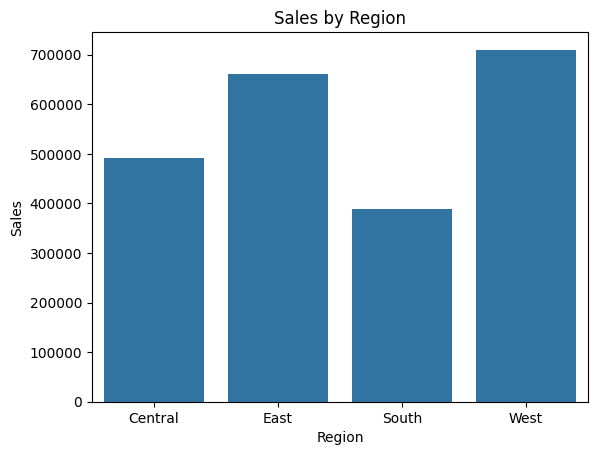

In [19]:
#Sales by Region
sales_by_region = df.groupby('Region')['Sales'].sum().reset_index()
print("Sales_by_Region:", sales_by_region)
print("------------------------------")

#Visulazation:
sns.barplot(data = sales_by_region, x='Region',y='Sales')
plt.title('Sales by Region')
plt.show()

Sales_By_Category:           Category        Sales
0        Furniture  723538.4757
1  Office Supplies  703212.8240
2       Technology  825856.1130
------------------------------------------


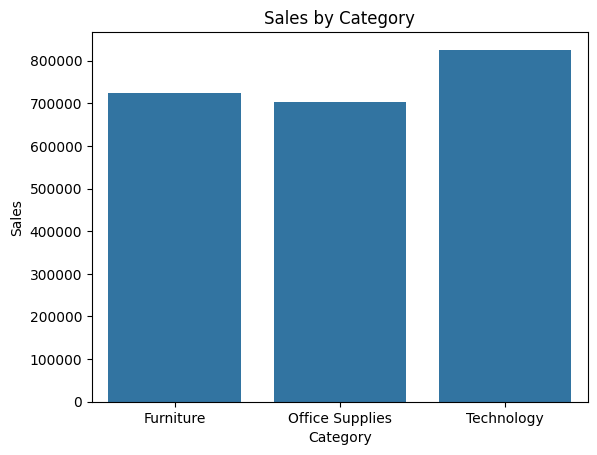

In [20]:
#Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
print('Sales_By_Category:', category_sales)
print('------------------------------------------')

#Visualization:
sns.barplot(data = category_sales, x ='Category', y='Sales')
plt.title('Sales by Category')
plt.show()

In [21]:
#Top 5 Products
top_products = (df.groupby('Product Name')['Sales']
                .sum()
                .sort_values(ascending=False)
                .head(5)
                .reset_index())
top_products

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479


In [22]:
#Monthly Sales Trend
Monthly_Sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
print('Monthly Sales:', Monthly_Sales)

Monthly Sales:     Year  Month        Sales
0   2015      1   14205.7070
1   2015      2    4519.8920
2   2015      3   55205.7970
3   2015      4   27906.8550
4   2015      5   23644.3030
5   2015      6   34322.9356
6   2015      7   33781.5430
7   2015      8   27117.5365
8   2015      9   81623.5268
9   2015     10   31453.3930
10  2015     11   77907.6607
11  2015     12   68167.0585
12  2016      1   18066.9576
13  2016      2   11951.4110
14  2016      3   32339.3184
15  2016      4   34154.4685
16  2016      5   29959.5305
17  2016      6   23599.3740
18  2016      7   28608.2590
19  2016      8   36818.3422
20  2016      9   63133.6060
21  2016     10   31011.7375
22  2016     11   70129.2995
23  2016     12   74543.6012
24  2017      1   16870.1810
25  2017      2   22978.8150
26  2017      3   51165.0590
27  2017      4   37385.0170
28  2017      5   56656.9080
29  2017      6   39724.4860
30  2017      7   38320.7830
31  2017      8   30542.2003
32  2017      9   69193.3909

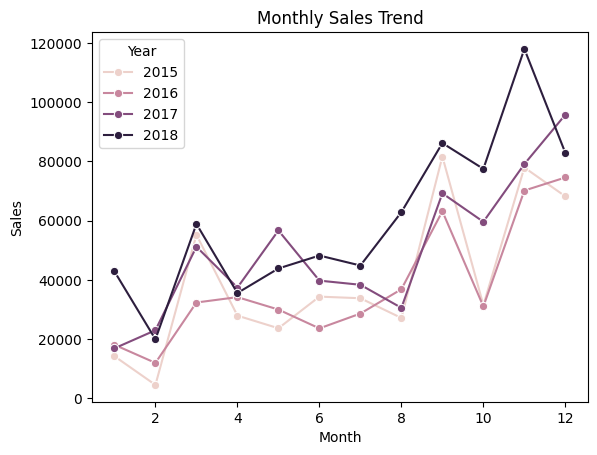

In [23]:
#Monthly Sales Trend Visualization
plt.figure()
sns.lineplot(data=Monthly_Sales, x='Month', y='Sales', hue='Year', marker='o')
plt.title('Monthly Sales Trend')
plt.show()

**Key Insights:**

1. Regional Performance:

    The West region generates the highest sales, indicating stronger customer demand compared to other regions.
2. Category Contribution

    The Technology category contributes the largest share of total revenue, making it the primary driver of business performance.
3. Product Concentration

    A small number of products contribute a significant portion of overall sales, showing a concentration of revenue among top-performing products (Pareto effect).
4. Seasonal Trends

    Sales exhibit noticeable seasonal patterns, with certain months consistently achieving higher sales, indicating time-based demand fluctuations.
5. Business Opportunity
    
    Regions and categories with lower sales performance present opportunities for growth through targeted marketing and strategic planning.